In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [53]:
df = clean_data.copy()

In [54]:
df.shape

(1773719, 38)

In [55]:
df.memory_usage(deep=True).sum()/(1024*1024)

np.float64(532.9509267807007)

In [56]:
df['mta_tax_amount'].describe()

d:\projects\data analysis\venv\Lib\site-packages\pandas\core\nanops.py:1524: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
d:\projects\data analysis\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
d:\projects\data analysis\venv\Lib\site-packages\pandas\core\nanops.py:725: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan


count    1773719.0
mean           NaN
std            0.0
min            0.0
25%            0.5
50%            0.5
75%            0.5
max            0.5
Name: mta_tax_amount, dtype: float64

In [57]:
df['mta_tax_amount'].quantile([0.9,0.99,0.995,0.999,0.9995,0.9999])

0.9000    0.5
0.9900    0.5
0.9950    0.5
0.9990    0.5
0.9995    0.5
0.9999    0.5
Name: mta_tax_amount, dtype: float64

In [58]:
df[(df['mta_tax_amount']>0.5)]

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,distance_difference,distance_ratio,pickup_borough,pickup_zone,pickup_service_type,dropoff_borough,dropoff_zone,dropoff_service_type,fare_type_zone_mismatch,fare_per_distance


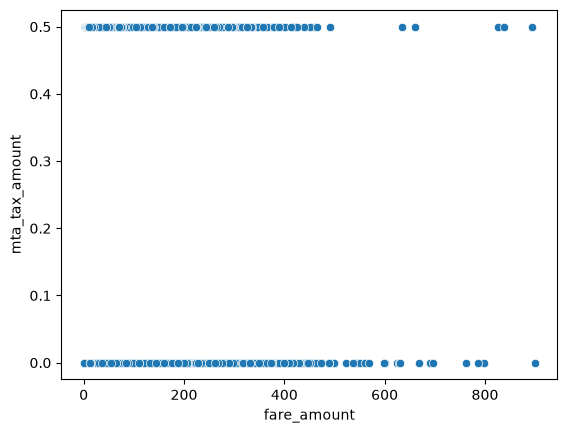

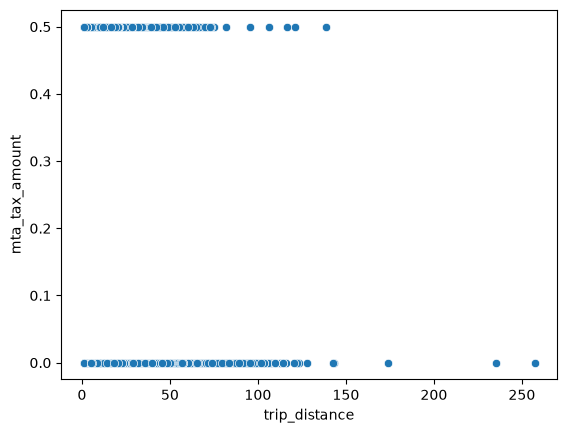

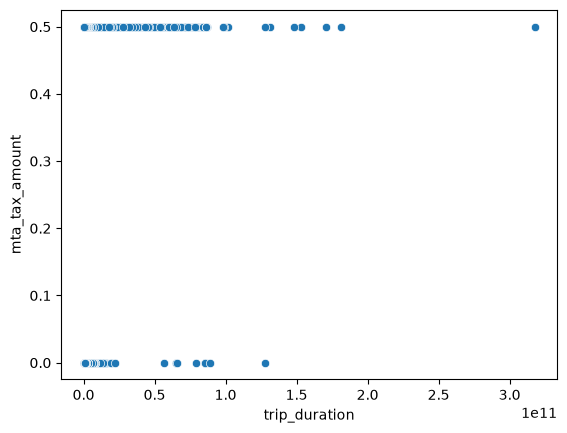

In [59]:
sns.scatterplot(
    x = df['fare_amount'],
    y = df['mta_tax_amount']
)
plt.show()
sns.scatterplot(
    x = df['trip_distance'],
    y = df['mta_tax_amount']
)
plt.show()
sns.scatterplot(
    x = df['trip_duration'],
    y = df['mta_tax_amount']
)
plt.show()

# remove mta_tax_amount > 1.0

In [60]:
df = df[df['mta_tax_amount'] < 1.0]

# change data type

In [61]:
df['mta_tax_amount'] = df['mta_tax_amount'].astype('float16')

In [62]:
df = df.reset_index(drop=True)

In [63]:
df.memory_usage(deep=True).sum()/(1024*1024)

np.float64(532.9509267807007)

# save back to clean data

In [64]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)